# Machine Learning Model Deployment

**Dataset:**
Sample from [IMDB (Internet Movie Database)](https://developer.imdb.com/non-commercial-datasets/)  

<small>

_About_
> _IMDb, formerly known as the Internet Movie Database, is an online database of information related to films, television series, podcasts, video games, and streaming content online – including cast, production crew and biographies, plot summaries, trivia, ratings, and fan and critical reviews._ ([Wikipedia](https://en.wikipedia.org/wiki/IMDb))
</small>

**Problem:**
Estimate which videos have an `averageRating > 8.0` with Pyspark.

## Libs

In [ ]:
import os
from pathlib import Path
import sys

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.types import StringType
from graphics.graphs import plot_confusion_matrix

## Carrega dataset

In [5]:
df = spark.read.parquet('./data/dataset_imdb_medium.parquet')
print(f'{df.count():_}')
df.limit(5).toPandas()

512_125


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
0,tt0058481,movie,Point of Order!,Point of Order!,0,1964,\N,97,Documentary,7.8,572
1,tt0059028,movie,Chemmeen,Chemmeen,0,1965,\N,140,"Drama,Romance",7.8,581
2,tt0066069,tvMovie,Mensch sein muß der Mensch,Mensch sein muß der Mensch,0,1970,\N,110,Comedy,7.8,14
3,tt0066694,tvMovie,Operation Walküre,Operation Walküre,0,1971,\N,199,History,7.8,43
4,tt0067185,movie,Harold and Maude,Harold and Maude,0,1971,\N,91,"Comedy,Drama,Romance",7.8,85242


## Checa valores nulos

In [7]:
print('=== NULL CHECK (titles) ===')

string_cols = [
    field.name
    for field in df.schema.fields
    if isinstance(field.dataType, StringType)
]

df.select([
    F.count(
        F.when(F.col(c) == r'\N', F.lit(1))
    ).alias(c)
    for c in string_cols
]).toPandas()

=== NULL CHECK (titles) ===


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
0,0,0,0,0,0,0,512125,56212,11059,0,0


## Trata nulos de runtimeMinutes

In [ ]:
df = df.withColumn(
    'runtimeMinutes',
    F.expr('try_cast(runtimeMinutes as double)')
)

runtime_mean = df.select(
    F.mean('runtimeMinutes')
).first()[0]

if runtime_mean is not None:
    df = df.withColumn(
        'runtimeMinutes',
        F.coalesce(
            F.col('runtimeMinutes'),
            F.lit(runtime_mean)
        )
    )

,runtimeMinutes
0,97.0
1,140.0
2,110.0
3,199.0
4,91.0
5,84.0
6,105.0
7,90.0
8,29.0
9,170.0


## Define target

In [9]:
df = df.withColumn(
    'Target',
    F.when(F.col('averageRating') > 7.5, 1).otherwise(0)
)
df.limit(5).toPandas()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes,Target
0,tt0058481,movie,Point of Order!,Point of Order!,0,1964,\N,97.0,Documentary,7.8,572,1
1,tt0059028,movie,Chemmeen,Chemmeen,0,1965,\N,140.0,"Drama,Romance",7.8,581,1
2,tt0066069,tvMovie,Mensch sein muß der Mensch,Mensch sein muß der Mensch,0,1970,\N,110.0,Comedy,7.8,14,1
3,tt0066694,tvMovie,Operation Walküre,Operation Walküre,0,1971,\N,199.0,History,7.8,43,1
4,tt0067185,movie,Harold and Maude,Harold and Maude,0,1971,\N,91.0,"Comedy,Drama,Romance",7.8,85242,1


## VectorAssembler das features

### Cast valores numéricos

In [12]:
df = (
    df
    .withColumn(
        'isAdult',
        F.when(F.col('isAdult') == r'\N', None)
        .otherwise(F.col('isAdult'))
        .cast('double')
    )
    .withColumn(
        'startYear',
        F.when(F.col('startYear') == r'\N', None)
        .otherwise(F.col('startYear'))
        .cast('double')
    )
    .withColumn(
        'numVotes',
        F.when(F.col('numVotes') == r'\N', None)
        .otherwise(F.col('numVotes'))
        .cast('double')
    )
)

In [13]:
assembler = VectorAssembler(
    inputCols=[
        'isAdult',
        'startYear',
        'runtimeMinutes',
        'numVotes'
    ],
    outputCol='features'
)

ml_df = (
    assembler
    .transform(df)
)

ml_df.limit(10).toPandas()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes,Target,features
0,tt0058481,movie,Point of Order!,Point of Order!,0.0,1964.0,\N,97.0,Documentary,7.8,572.0,1,"[0.0, 1964.0, 97.0, 572.0]"
1,tt0059028,movie,Chemmeen,Chemmeen,0.0,1965.0,\N,140.0,"Drama,Romance",7.8,581.0,1,"[0.0, 1965.0, 140.0, 581.0]"
2,tt0066069,tvMovie,Mensch sein muß der Mensch,Mensch sein muß der Mensch,0.0,1970.0,\N,110.0,Comedy,7.8,14.0,1,"[0.0, 1970.0, 110.0, 14.0]"
3,tt0066694,tvMovie,Operation Walküre,Operation Walküre,0.0,1971.0,\N,199.0,History,7.8,43.0,1,"[0.0, 1971.0, 199.0, 43.0]"
4,tt0067185,movie,Harold and Maude,Harold and Maude,0.0,1971.0,\N,91.0,"Comedy,Drama,Romance",7.8,85242.0,1,"[0.0, 1971.0, 91.0, 85242.0]"
5,tt0070874,movie,Veronica se întoarce,Veronica se întoarce,0.0,1973.0,\N,84.0,"Family,Fantasy,Musical",7.8,369.0,1,"[0.0, 1973.0, 84.0, 369.0]"
6,tt0073160,tvMovie,In This House of Brede,In This House of Brede,0.0,1975.0,\N,105.0,Drama,7.8,344.0,1,"[0.0, 1975.0, 105.0, 344.0]"
7,tt0079679,movie,Autumn Marathon,Osenniy marafon,0.0,1979.0,\N,90.0,"Comedy,Drama,Romance",7.8,4125.0,1,"[0.0, 1979.0, 90.0, 4125.0]"
8,tt0079986,short,The Tale of Tales,Skazka skazok,0.0,1979.0,\N,29.0,"Animation,Drama,Short",7.8,4520.0,1,"[0.0, 1979.0, 29.0, 4520.0]"
9,tt0080228,tvMovie,Highway 40 West,Highway 40 West,0.0,1981.0,\N,170.0,Documentary,7.8,11.0,1,"[0.0, 1981.0, 170.0, 11.0]"


In [14]:
print(f'{df.count():_}')

512_125


## Split do dataset

In [15]:
train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)

print(f'#Linhas treino: {train_df.count()}')
print(f'#Linhas de teste: {test_df.count()}')


#Linhas treino: 409923
#Linhas de teste: 102202


In [16]:
print('\nDistribuição do Target:')
test_df.groupBy('Target').count().orderBy('Target').toPandas()


Distribuição do Target:


,Target,count
0,0,79858
1,1,22344


## Model training

In [18]:
model_rf = RandomForestClassifier(
    featuresCol='features',
    labelCol='Target',
    numTrees=200,
    maxDepth=8,
    seed=42
)

model = model_rf.fit(train_df)

26/08/30 16:54:14 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/08/30 16:54:33 WARN DAGScheduler: Broadcasting large task binary with size 1792.5 KiB
26/08/30 16:54:41 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
26/08/30 16:54:51 WARN DAGScheduler: Broadcasting large task binary with size 1054.1 KiB
26/08/30 16:54:51 WARN DAGScheduler: Broadcasting large task binary with size 6.4 MiB
26/08/30 16:55:04 WARN DAGScheduler: Broadcasting large task binary with size 1953.6 KiB


## Tests

In [19]:
preds = model.transform(train_df)

In [20]:

print('\nPrevisões:')
preds.limit(5).toPandas()


Previsões:


26/08/30 16:55:06 WARN DAGScheduler: Broadcasting large task binary with size 1716.8 KiB
26/08/30 16:55:06 WARN DAGScheduler: Broadcasting large task binary with size 1665.6 KiB


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes,Target,features,rawPrediction,probability,prediction
0,tt0044952,movie,Nagarik,Nagarik,0.0,1977.0,\N,127.0,Drama,7.8,265.0,1,"[0.0, 1977.0, 127.0, 265.0]","[173.2149861103956, 26.785013889604368]","[0.8660749305519782, 0.13392506944802185]",0.0
1,tt0051863,movie,Life Is a Circus,Life Is a Circus,0.0,1960.0,\N,84.0,Comedy,7.7,126.0,1,"[0.0, 1960.0, 84.0, 126.0]","[185.19977119687263, 14.800228803127327]","[0.9259988559843633, 0.07400114401563665]",0.0
2,tt0052784,movie,Skeleton of Mrs. Morales,El esqueleto de la señora Morales,0.0,1960.0,\N,85.0,"Comedy,Crime,Drama",7.7,2635.0,1,"[0.0, 1960.0, 85.0, 2635.0]","[184.66833668804134, 15.331663311958573]","[0.9233416834402071, 0.0766583165597929]",0.0
3,tt0052961,movie,Kapo,Kapò,0.0,1960.0,\N,116.0,"Drama,War",7.6,2950.0,1,"[0.0, 1960.0, 116.0, 2950.0]","[182.4415503092091, 17.558449690790855]","[0.9122077515460456, 0.0877922484539543]",0.0
4,tt0053106,movie,Letter Never Sent,Neotpravlennoye pismo,0.0,1960.0,\N,96.0,"Adventure,Drama",7.8,4910.0,1,"[0.0, 1960.0, 96.0, 4910.0]","[184.66833668804134, 15.331663311958573]","[0.9233416834402071, 0.0766583165597929]",0.0


In [21]:
preds.groupBy('prediction').count().show()

26/08/30 16:55:07 WARN DAGScheduler: Broadcasting large task binary with size 1712.0 KiB


+----------+------+
|prediction| count|
+----------+------+
|       0.0|407947|
|       1.0|  1976|
+----------+------+



26/08/30 16:55:09 WARN DAGScheduler: Broadcasting large task binary with size 1688.4 KiB


In [22]:
preds.select('Target', 'prediction', 'probability').show(5, truncate=False)

26/08/30 16:55:09 WARN DAGScheduler: Broadcasting large task binary with size 1700.5 KiB


+------+----------+----------------------------------------+
|Target|prediction|probability                             |
+------+----------+----------------------------------------+
|1     |0.0       |[0.8660749305519782,0.13392506944802185]|
|1     |0.0       |[0.9259988559843633,0.07400114401563665]|
|1     |0.0       |[0.9233416834402071,0.0766583165597929] |
|1     |0.0       |[0.9122077515460456,0.0877922484539543] |
|1     |0.0       |[0.9233416834402071,0.0766583165597929] |
+------+----------+----------------------------------------+
only showing top 5 rows


In [23]:
prob_df = preds.select(
    'Target',
    vector_to_array('probability')[1].alias('prob_1')
)

prob_df.groupBy('Target').agg(
    F.count('*').alias('count'),
    F.min('prob_1').alias('min_prob_1'),
    F.max('prob_1').alias('max_prob_1'),
    F.avg('prob_1').alias('avg_prob_1')
).orderBy('Target').show()

26/08/30 16:55:10 WARN DAGScheduler: Broadcasting large task binary with size 1726.8 KiB


+------+------+-------------------+------------------+------------------+
|Target| count|         min_prob_1|        max_prob_1|        avg_prob_1|
+------+------+-------------------+------------------+------------------+
|     0|319810|0.07372241273295979|0.5297977585231064|0.1975430597722517|
|     1| 90113|0.07385217130033406|0.5297977585231064|0.2988748246325716|
+------+------+-------------------+------------------+------------------+



26/08/30 16:55:12 WARN DAGScheduler: Broadcasting large task binary with size 1705.2 KiB


## Model eval

### areaUnderROC

In [ ]:
auc = BinaryClassificationEvaluator(
    labelCol='Target',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
).evaluate(preds)

print(f'ROC-AUC: {auc:.4f}')

26/08/30 16:55:12 WARN DAGScheduler: Broadcasting large task binary with size 1698.7 KiB


ROC-AUC: 0.7357


### BinaryClassificationEvaluator

In [ ]:
pr_auc = BinaryClassificationEvaluator(
    labelCol='Target',
    rawPredictionCol='rawPrediction',
    metricName='areaUnderPR'
).evaluate(preds)

print(f'PR-AUC: {pr_auc:.4f}')

26/08/30 16:55:15 WARN DAGScheduler: Broadcasting large task binary with size 1698.7 KiB


PR-AUC: 0.4057


### MulticlassClassificationEvaluator (accuracy, f1-score, etc)

In [ ]:
evaluator = MulticlassClassificationEvaluator(
    labelCol='Target',
    predictionCol='prediction'
)

accuracy = evaluator.setMetricName(
    'accuracy'
).evaluate(preds)


f1 = evaluator.setMetricName(
    'f1'
).evaluate(preds)

precision = evaluator.setMetricName(
    'weightedPrecision'
).evaluate(preds)


recall = evaluator.setMetricName(
    'weightedRecall'
).evaluate(preds)


print(f'\nAccuracy: {accuracy:.4f}')
print(f'F1-score: {f1:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')

26/08/30 16:55:18 WARN DAGScheduler: Broadcasting large task binary with size 1711.7 KiB
26/08/30 16:55:21 WARN DAGScheduler: Broadcasting large task binary with size 1711.7 KiB
26/08/30 16:55:23 WARN DAGScheduler: Broadcasting large task binary with size 1711.7 KiB
26/08/30 16:55:25 WARN DAGScheduler: Broadcasting large task binary with size 1711.7 KiB



Accuracy: 0.7811
F1-score: 0.6896
Precision: 0.7403
Recall: 0.7811


### Confusion matrix

26/08/30 16:55:31 WARN DAGScheduler: Broadcasting large task binary with size 1712.6 KiB
26/08/30 16:55:33 WARN DAGScheduler: Broadcasting large task binary with size 1688.5 KiB


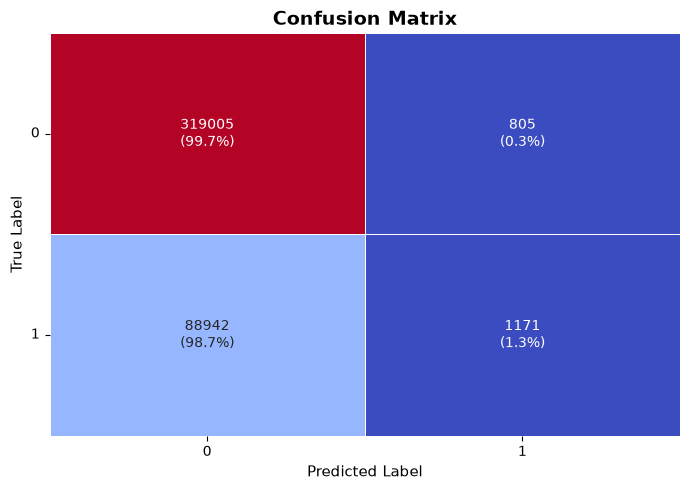

In [ ]:
plot_confusion_matrix(preds)